## Probability theory - solutions

This notebook contains exercises to test your understanding on the probability chapter of the course

-------------------------

To solve the problems in Python, you'll need to import the following libraries:

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import scipy

## Problem 1: unfair coins
We are given the task of studying a set of $n = 100$ equivalent unfair coins. 

We conduct a series of experiments, in which we toss all of our coins at once. We count how many heads we obtain each time, and obtain a value for the probability $prob(k)$ of obtaining $k$ heads across all of the experiments. The data are summarised in the file *unfair_coins_data.csv*, which you can import using the following line of code:

In [2]:
unfair_coins_data = np.loadtxt("probability_problems_files/unfair_coins_data.csv", delimiter=",", skiprows=1)
data_ks = unfair_coins_data[:, 0].astype(int)
data_ps = unfair_coins_data[:, 1]

**Q1**: Plot a histogram showing $p(k)$ as a function of $k$

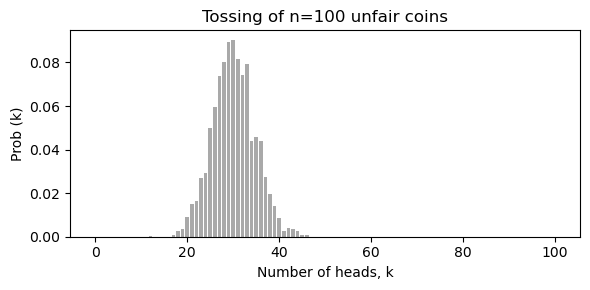

In [3]:
#Solution
plt.figure(figsize=(6, 3))
plt.bar(data_ks, data_ps, width=0.8, color = 'darkgrey')
plt.xlabel("Number of heads, k")
plt.ylabel("Prob (k)")
plt.title("Tossing of n=100 unfair coins")
plt.tight_layout()
plt.show()

**Q2**: Calculate the average number of heads for this distribution

In [4]:
#Solution 
# Average (expected value)
k_mean = np.sum(data_ks * data_ps)

print("Average k =", k_mean)

Average k = 30.11551809618245


**Q3**: What can you deduce from this value? If we look at coins individually, are they more likely to land on heads or tails?

In [5]:
#Solution: 
#Given that our coins are all equivalent, tossing n=100 coins at once is equivalent to tossing 1 coin a hundred times. This means that, based on all the tosses, for every individual coin we get heads in about 30% of tosses

**Q4**: What is your estimate for $p$, the probability of obtaining tails in 1 toss?

In [7]:
#Solution 
#The probability of obtaining tails in 1 toss is close to p=0.3

**Q5**: It's time to test this! Run the following cell and play around with the interactive distribution of $n=100$ coins. You can change the value of $p$, the probability of 1 coin falling on heads, to try to match the model to the data plotted in black. What value of $p$ gives the best fit to the data?

In [6]:
#Interactive simulation

n=100

def binom_pmf(k, p, n=100):
    """Binomial pmf for X ~ Bin(n, p)"""
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

def plot_binomial(p=0.5):
    ks = np.arange(0, n+1)
    probs = np.array([binom_pmf(k, p, n) for k in ks])

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    # Background layer (your provided data)
    markerline, stemlines, baseline = ax.stem(
            data_ks, data_ps, basefmt=" "
        )
    plt.setp(markerline, alpha=0.8, color = 'black')
    plt.setp(stemlines, alpha=0.8, color = 'black')
    markerline.set_zorder(1)
    stemlines.set_zorder(1)

    # Moving interactive distribution
    ax.bar(ks, probs, alpha=0.35, zorder=2)

    # Highlight mean k=np (optional but nice)
    k_mean = int(round(n * p))
    ax.bar([k_mean], [binom_pmf(k_mean, p, n)], alpha=1.0, zorder=3)

    ax.set_xlim(-1, n+1)
    ax.set_xlabel("k")
    ax.set_ylabel("Probability mass")
    ax.set_title(f"Finding p(1 head) in unfair die")
    plt.tight_layout()
    plt.show()

interact(plot_binomial,p=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.5, description="p (1 head)"))

interactive(children=(FloatSlider(value=0.5, description='p (1 head)', max=0.99, min=0.01, step=0.01), Output(…

<function __main__.plot_binomial(p=0.5)>

## Problem 2: cars arriving at a crossing

Colour boredom has spread around the city of London, and only blue, yellow and grey cars are allowed to circulate. We want to study the arrival of cars at a zebra crossing as a Poissonian process. We start by conducting an experiment 2h long experiment, in which we count the number of cars of each type arriving at the crossing every minute. The data of this experiment can be imported from the file crossing_cars_data.csv using the following code snippet:

In [7]:
crossing_cars_data = np.loadtxt("probability_problems_files/crossing_cars_data.csv", delimiter=",", skiprows=1)
time = crossing_cars_data[:, 0].astype(int)
yellow_cars = crossing_cars_data[:, 1].astype(int)
blue_cars = crossing_cars_data[:, 2].astype(int)
grey_cars = crossing_cars_data[:, 3].astype(int)

**Q1**: Plot the number of cars of each type as a function of time. From the plot, estimate the following: 
- The car colour with the highest count per minute
- The car colour with the largest fluctuations in numbers
- The most likely number of cars for each type

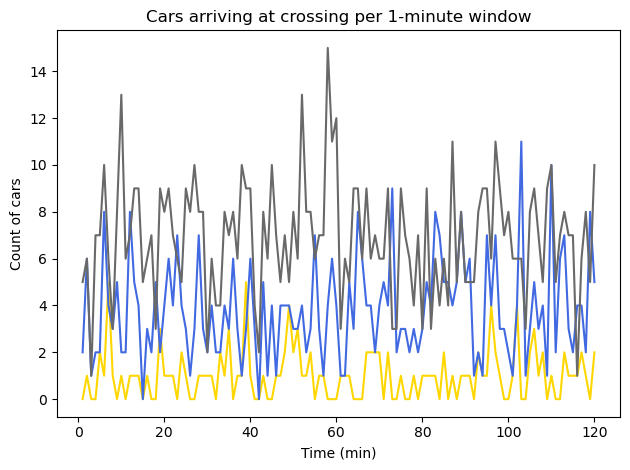

Yellow 
mean: 1.0166666666666666 
std: 1.0644508234557177 
mode: 1
Blue 
mean: 3.85 
std: 2.166602563154273 
mode: 4
Grey 
mean: 6.891666666666667 
std: 2.4657515194267963 
mode: 6


In [8]:
#Solution
plt.figure()
plt.plot(time, yellow_cars, color="gold")
plt.plot(time, blue_cars, color="royalblue")
plt.plot(time, grey_cars, color="dimgrey")
plt.xlabel("Time (min)")
plt.ylabel("Count of cars")
plt.title("Cars arriving at crossing per 1-minute window")
plt.tight_layout()
plt.show()

#Find mean of each colour
mean_yellow = np.mean(yellow_cars)
mean_blue= np.mean(blue_cars)
mean_grey = np.mean(grey_cars)

#Find standard deviation of each dataset 
std_yellow = np.std(yellow_cars)
std_blue = np.std(blue_cars)
std_grey =  np.std(grey_cars)

#Find mode of each dataset 
mode_yellow = scipy.stats.mode(yellow_cars)[0]
mode_blue = scipy.stats.mode(blue_cars)[0]
mode_grey =  scipy.stats.mode(grey_cars)[0]

print(f'Yellow \nmean: {mean_yellow} \nstd: {std_yellow} \nmode: {mode_yellow}')
print(f'Blue \nmean: {mean_blue} \nstd: {std_blue} \nmode: {mode_blue}')
print(f'Grey \nmean: {mean_grey} \nstd: {std_grey} \nmode: {mode_grey}')

**Q2**: Transform the datasets into three probability distributions (empirical PMFs) by considering: 
$$
P(k)=\frac{\#\text{ minutes with count } k}{120}
$$


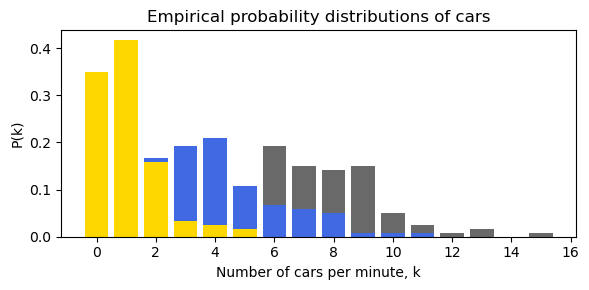

In [ ]:
#Solution 
yellow_counts = np.bincount(yellow_cars) #how many times value k occurred
yellow_pmf = yellow_counts / yellow_counts.sum() #empirical pmf
yellow_k= np.arange(len(yellow_counts))
yellow_mask = yellow_counts > 0  

blue_counts = np.bincount(blue_cars) #how many times value k occurred      
blue_pmf = blue_counts / blue_counts.sum() #empirical pmf 
blue_k= np.arange(len(blue_counts))
blue_mask = blue_counts > 0

grey_counts = np.bincount(grey_cars) #how many times value k occurred     
grey_pmf = grey_counts / grey_counts.sum() #empirical pmf    
grey_k= np.arange(len(grey_counts))
grey_mask = grey_counts > 0  

plt.figure(figsize=(6, 3))
plt.bar(grey_k, grey_pmf, width=0.8, color = 'dimgrey')
plt.bar(blue_k, blue_pmf, width=0.8, color = 'royalblue')
plt.bar(yellow_k, yellow_pmf, width=0.8, color = 'gold')
plt.xlabel("Number of cars per minute, k")
plt.ylabel("P(k)")
plt.title("Empirical probability distributions of cars")
plt.tight_layout()
plt.show()



**Q3**: Use the mean values you calculated in Q1 as an estimate for $\lambda$ and find the corresponding Poisson probability terms with: 
$$
P(k)=\frac{{\lambda}^{k}}{k!}·{e}^{-\lambda}
$$
Compare the Poissonian distributions with the empirical distributions from Q2 in a plot.


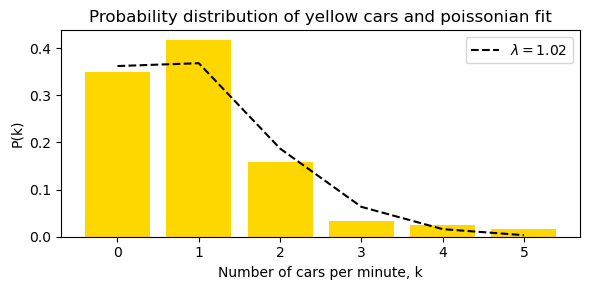

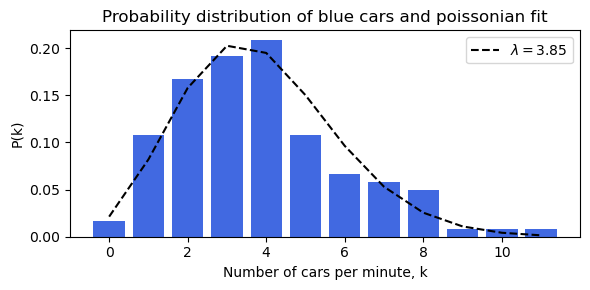

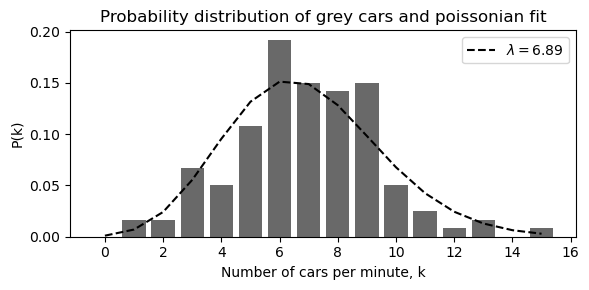

In [ ]:
#solution 
yellow_poisson = np.array([np.exp(-mean_yellow) * (mean_yellow ** int(k)) / math.factorial(int(k))
    for k in yellow_k])

plt.figure(figsize=(6, 3))
plt.bar(yellow_k, yellow_pmf, width=0.8, color = 'gold')
plt.plot(yellow_k, yellow_poisson, color = 'black', ls='--', label=rf"$\lambda = {mean_yellow:.2f}$")
plt.xlabel("Number of cars per minute, k")
plt.ylabel("P(k)")
plt.title("Probability distribution of yellow cars and poissonian fit")
plt.legend()
plt.tight_layout()
plt.show()


blue_poisson = np.array([np.exp(-mean_blue) * (mean_blue ** int(k)) / math.factorial(int(k))
    for k in blue_k])

plt.figure(figsize=(6, 3))
plt.bar(blue_k, blue_pmf, width=0.8, color = 'royalblue')
plt.plot(blue_k, blue_poisson, color = 'black', ls='--', label=rf"$\lambda = {mean_blue:.2f}$")
plt.xlabel("Number of cars per minute, k")
plt.ylabel("P(k)")
plt.title("Probability distribution of blue cars and poissonian fit")
plt.legend()
plt.tight_layout()
plt.show()


grey_poisson = np.array([np.exp(-mean_grey) * (mean_grey ** int(k)) / math.factorial(int(k))
    for k in grey_k])

plt.figure(figsize=(6, 3))
plt.bar(grey_k, grey_pmf, width=0.8, color = 'dimgrey')
plt.plot(grey_k, grey_poisson, color = 'black', ls='--', label=rf"$\lambda = {mean_grey:.2f}$")
plt.xlabel("Number of cars per minute, k")
plt.ylabel("P(k)")
plt.title("Probability distribution of grey cars and poissonian fit")
plt.legend()
plt.tight_layout()
plt.show()




## Problem 3: a 2D uniform distribution
We are going to study a 2D uniform distribution in the $(x,y)$ coordinates space

Consider a square dartboard of side length $l = 2$, like the one shown in the cell below:

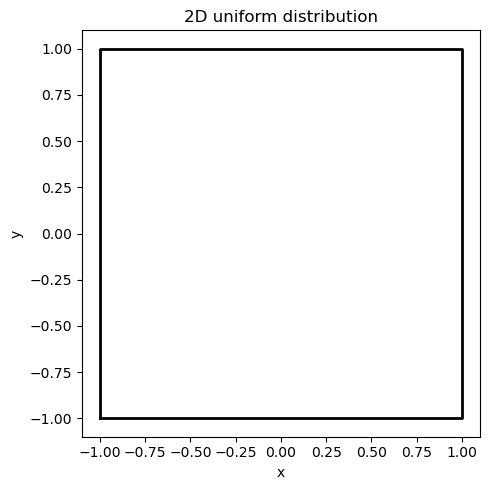

In [12]:
#Square plot
square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]

plt.figure(figsize=(5, 5))
plt.plot(square_x, square_y, linewidth=2, color='black')
plt.title("2D uniform distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

**Q1**: Let's start by modelling the throw of $N = 10000$ dards that land on the board. Can you generate an uniform distribution of hits in $(x,y)$ using *np.random*?

In [13]:
#Solution
N = 10000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

**Q2**: Represent the distribution of hits on the dardboard

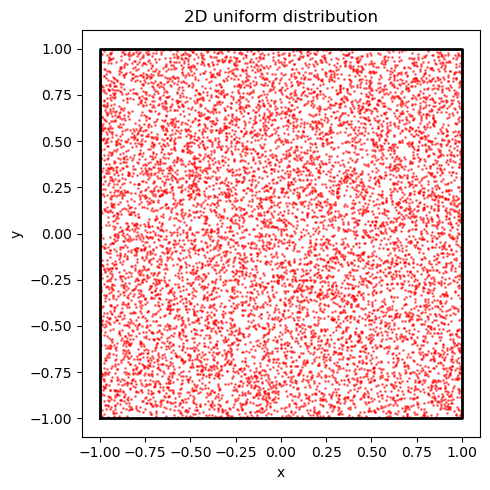

In [14]:
#Solution 
square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]

plt.figure(figsize=(5, 5))
plt.scatter(x, y, s=1, alpha=0.5, color = 'red')
plt.plot(square_x, square_y, linewidth=2, color='black')
plt.title("2D uniform distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

**Q3**: If we divide the dardboard into 4 equal squares, as shown below, what is the probability that a newly thrown dard hits the upper right one?

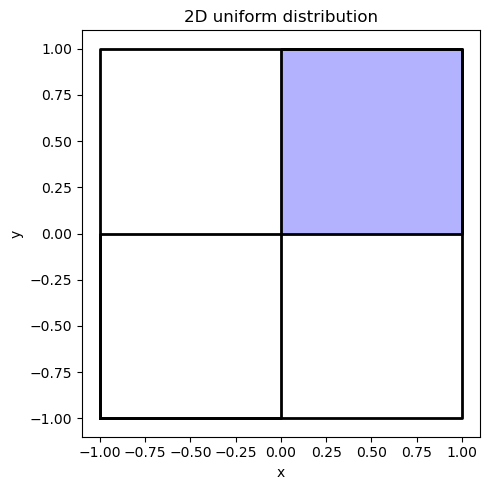

In [15]:
#Square with 4 quadrants

square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]
square1_x = [-1,  0,  0, -1, -1]
square1_y = [-1, -1,  0,  0, -1]
square2_x = [0,  1,  1, 0, 0]
square2_y = [0, 0,  1,  1, 0]

plt.figure(figsize=(5, 5))
plt.plot(square_x, square_y, linewidth=2, color='black')
plt.plot(square1_x, square1_y, linewidth=2, color='black')
plt.plot(square2_x, square2_y, linewidth=2, color='black')
plt.fill(square2_x, square2_y, color="blue", alpha=0.3)
plt.title("2D uniform distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [18]:
#Solution:
#The probability is 1/4

**Q4**: Let's test your answer! Write a code snippet that counts how many of your $N=10000$ dards fell on the upper right quadrant and plot the results

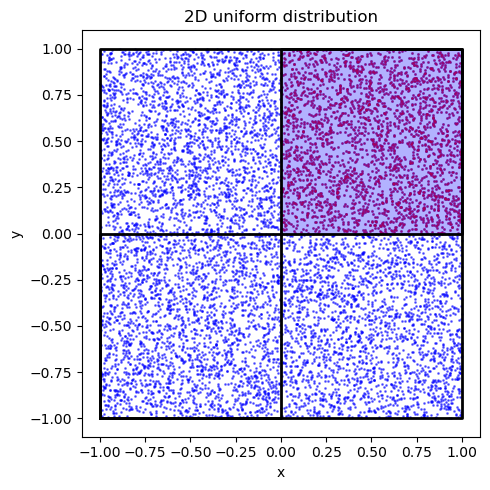

25.07 % of dards hit the upper right quadrant


In [16]:
#Solution

#Filter definition
def square_filter(x_coords, y_coords):
    mask = (x_coords > 0) & (y_coords>0)
    upper_right_x, upper_right_y = (x_coords[mask], y_coords[mask])
    return upper_right_x, upper_right_y

#Filter hits
(filtered_x, filtered_y) = square_filter(x, y)

#plot
square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]
square1_x = [-1,  0,  0, -1, -1]
square1_y = [-1, -1,  0,  0, -1]
square2_x = [0,  1,  1, 0, 0]
square2_y = [0, 0,  1,  1, 0]

plt.figure(figsize=(5, 5))
plt.plot(square_x, square_y, linewidth=2, color='black')
plt.plot(square1_x, square1_y, linewidth=2, color='black')
plt.plot(square2_x, square2_y, linewidth=2, color='black')
plt.scatter(x, y, s=1, alpha=0.5, color = 'blue')
plt.scatter(filtered_x, filtered_y, s=1, alpha=0.5, color = 'red')
plt.fill(square2_x, square2_y, color="blue", alpha=0.3)
plt.title("2D uniform distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

print(f'{len(filtered_x)*100/len(x)} % of dards hit the upper right quadrant')


This example is the basis of Monte Carlo simulations, in which repeated random samples are produced to solve a deterministic problem. Monte Carlo methods have diverse applications ranging from the generation of pseudo-random numbers to uncertainty propagation. 


Following up on the previous task, we will now use a Monte Carlo method to estimate the irrational number $\pi$ . 

Consider the area of the square dardboard above, with side $l = 2$: 

$A_s = l · l = 4$

We can embed inside it a circle of radius $R = 1$, and area: 

$A_c = \pi R^{2} = \pi$

The fraction of points lying inside the circle will be equal to the ratio between the two areas:

$f = A_c/A_s = \pi /4 $

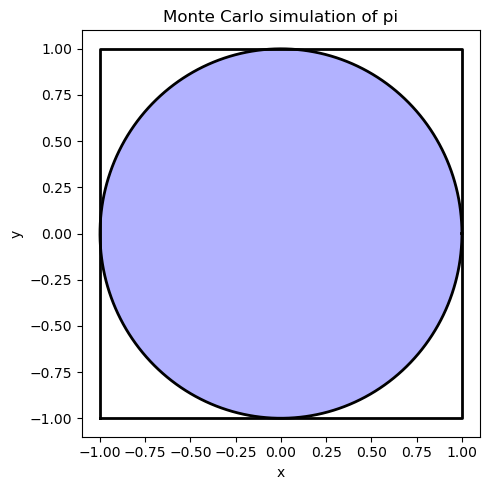

In [17]:
#square with circle
theta = np.linspace(0, 2*np.pi, 400)
square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, color='black')
plt.fill(np.cos(theta), np.sin(theta), color="blue", alpha=0.3)
plt.plot(square_x, square_y, linewidth=2, color='black')
plt.title("Monte Carlo simulation of pi")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

**Q5**: Write down another function that filters the points falling inside the circle

In [18]:
#Solution
def point_filter(x_coords, y_coords, r=1.0):
    x_coords = np.asarray(x_coords)
    y_coords = np.asarray(y_coords)

    mask = x_coords**2 + y_coords**2 < r**2

    inside = (x_coords[mask], y_coords[mask])
    outside = (x_coords[~mask], y_coords[~mask])
    return inside, outside

**Q6**: Run your function on the $(x, y)$ points generated earlier and plot the results

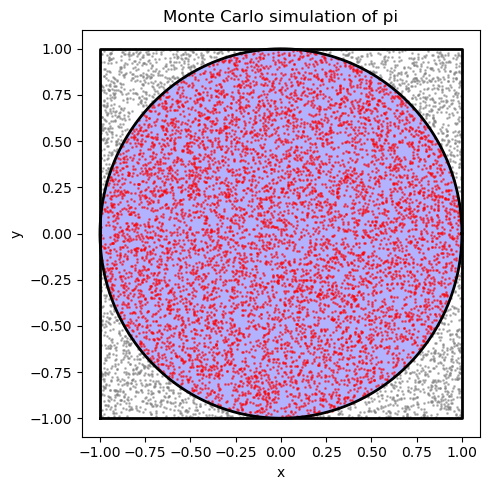

In [19]:
#Solution

(inside_x, inside_y), (outside_x, outside_y) = point_filter(x, y)

theta = np.linspace(0, 2*np.pi, 400)
square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, color='black')
plt.fill(np.cos(theta), np.sin(theta), color="blue", alpha=0.3)
plt.plot(square_x, square_y, linewidth=2, label="Square", color='black')
plt.scatter(inside_x, inside_y, s=1, alpha=0.5, color = 'red')
plt.scatter(outside_x, outside_y, s=1, alpha=0.5, color= 'grey')
plt.title("Monte Carlo simulation of pi")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

**Q7**: What is the corresponding estimate for $\pi$?

In [20]:
#Solution:

print(f'Estimate of pi: {len(inside_x)*4/N}')

Estimate of pi: 3.1452
